In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
df =pd.read_csv('../data/Customer-Churn.csv')

In [9]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [7]:
df.shape

(7043, 21)

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


# how many customers are churned ?

In [12]:
churn_count = df['Churn'].value_counts()
print(churn_count)

Churn
No     5174
Yes    1869
Name: count, dtype: int64


In [13]:
churn_percent = df['Churn'].value_counts(normalize=True)*100
print(churn_percent)

Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


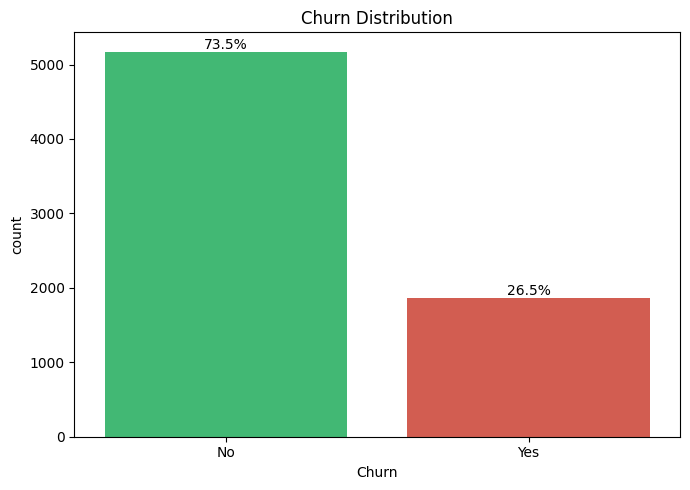

In [34]:
plt.figure(figsize=(7,5))
sns.countplot(data=df,x='Churn',hue='Churn', palette=['#2ecc71', '#e74c3c'])
plt.title('Churn Distribution')

for i,v in enumerate(churn_count):
    plt.text(i,v+30,f'{churn_percent.iloc[i]:.1f}%',ha='center')
plt.tight_layout()
plt.savefig('../data/churn_distribution.png')
plt.show()



# Churn by contract type

In [44]:
contract_churn = (df.groupby('Contract')['Churn'].value_counts(normalize=True).unstack())*100
print(contract_churn)

Churn                  No        Yes
Contract                            
Month-to-month  57.290323  42.709677
One year        88.730482  11.269518
Two year        97.168142   2.831858


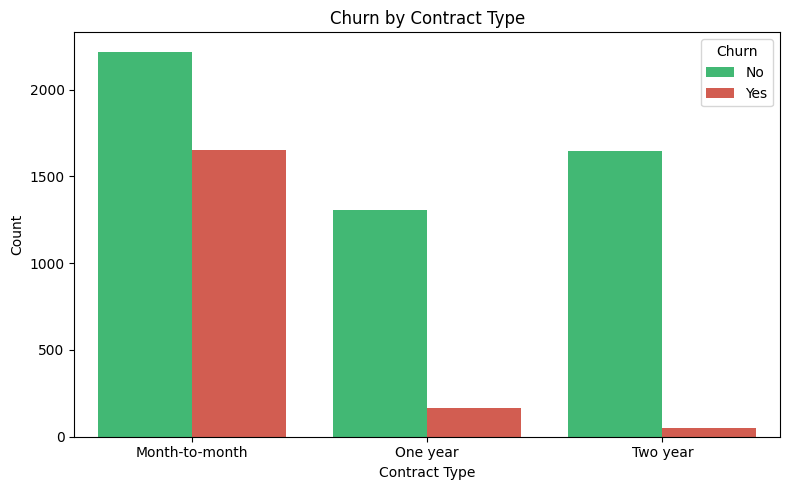

In [42]:
plt.figure(figsize=(8,5))
sns.countplot(data=df,hue='Churn',x='Contract',palette=['#2ecc71', '#e74c3c'])
plt.title('Churn by Contract Type')
plt.xlabel('Contract Type')
plt.ylabel('Count')
plt.legend(title='Churn')
plt.tight_layout()
plt.show()


# Churn by Tenure

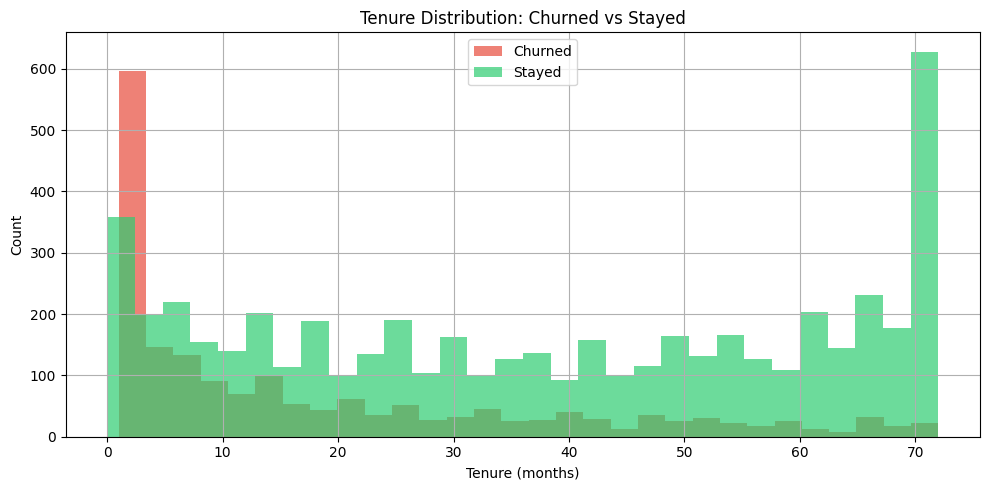

In [47]:
plt.figure(figsize=(10, 5))
df[df['Churn']=='Yes']['tenure'].hist(bins=30, alpha=0.7, color='#e74c3c', label='Churned')
df[df['Churn']=='No']['tenure'].hist(bins=30, alpha=0.7, color='#2ecc71', label='Stayed')
plt.xlabel('Tenure (months)')
plt.ylabel('Count')
plt.title('Tenure Distribution: Churned vs Stayed')
plt.legend()
plt.tight_layout()
plt.show()

In [48]:
# Average tenure

print("Avg tenure - Churned:", df[df['Churn']=='Yes']['tenure'].mean().round(1))
print("Avg tenure - Stayed:", df[df['Churn']=='No']['tenure'].mean().round(1))

Avg tenure - Churned: 18.0
Avg tenure - Stayed: 37.6


# Churn by monthly charges

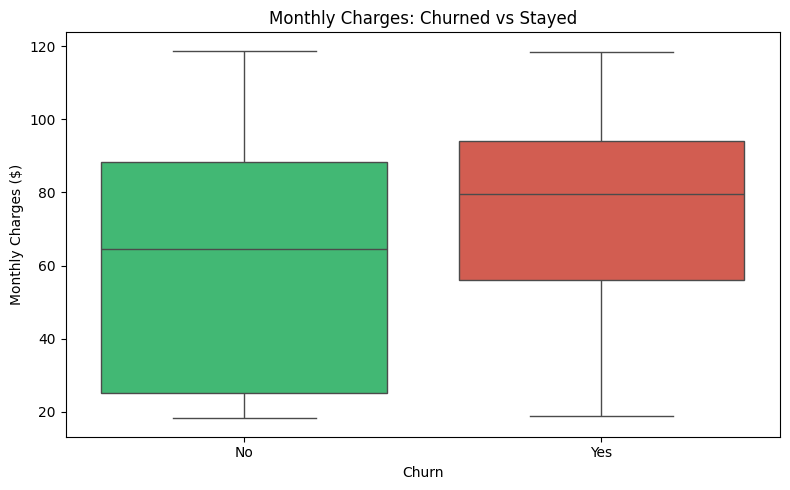

In [51]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='Churn',hue='Churn' , y='MonthlyCharges', palette=['#2ecc71', '#e74c3c'])
plt.title('Monthly Charges: Churned vs Stayed')
plt.xlabel('Churn')
plt.ylabel('Monthly Charges ($)')
plt.tight_layout()
plt.show()

In [50]:
print(df.groupby('Churn')['MonthlyCharges'].describe())

        count       mean        std    min    25%     50%   75%     max
Churn                                                                  
No     5174.0  61.265124  31.092648  18.25  25.10  64.425  88.4  118.75
Yes    1869.0  74.441332  24.666053  18.85  56.15  79.650  94.2  118.35


# Churn by internet services

In [53]:
internet_churn = df.groupby('InternetService')['Churn'].value_counts(normalize=True).unstack()*100
print(internet_churn)

Churn                   No        Yes
InternetService                      
DSL              81.040892  18.959108
Fiber optic      58.107235  41.892765
No               92.595020   7.404980


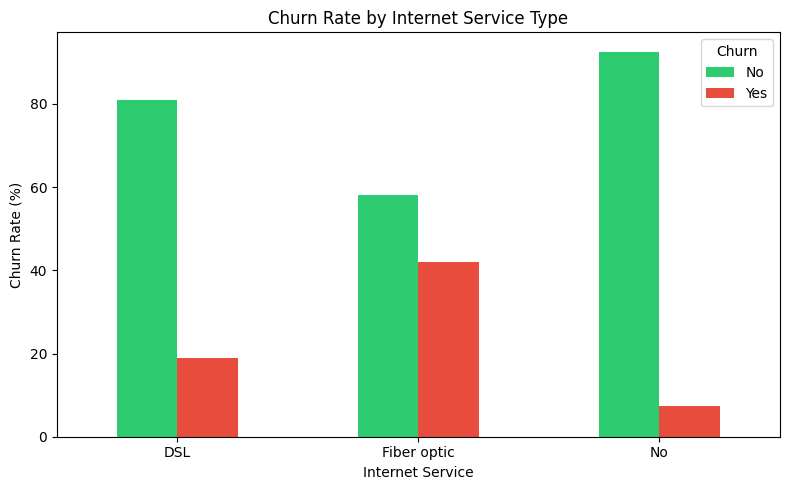

In [60]:
internet_churn.plot(kind='bar', color=['#2ecc71','#e74c3c'], figsize=(8, 5))
plt.title('Churn Rate by Internet Service Type')
plt.xlabel('Internet Service')
plt.ylabel('Churn Rate (%)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# Correlation Heatmap (Numeric Features)

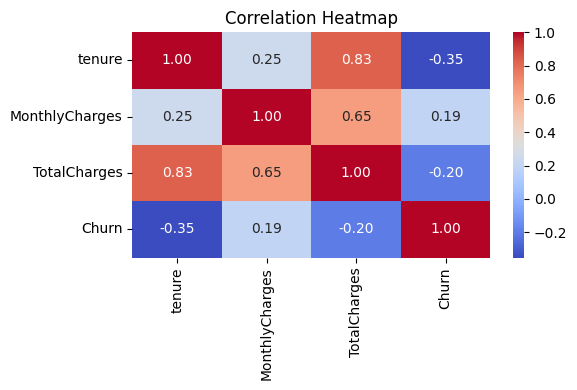

In [64]:
numeric_df = df[['tenure', 'MonthlyCharges', 'TotalCharges']].copy()

numeric_df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
numeric_df['Churn'] = (df['Churn'] == 'Yes').astype(int)


plt.figure(figsize=(6, 4))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()